# What are the most demanded skills for the top 5 most popular data roles?

## Methodology
1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill percentage
4. Plot final findings


In [3]:
#Turn off warning notification
import warnings
warnings.filterwarnings("ignore")

import datasets
datasets.logging.set_verbosity_error()


### Import Libraries and Data

In [4]:
# Import library
import pandas as pd
import numpy as np
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

### Filter Data for SEA (Southeast Asia)

In [5]:
# Countries belong to Southeast Asia
countries = ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia' , 'Myanmar'
             , 'Philippines', 'Singapore', 'Thailand', 'East Timor', 'Vietnam']

In [6]:
df_SEA = df[df['job_country'].isin(countries)]

### Explode Skills

Converts the job_skills column from string representations of lists into actual list objects and then expands these lists so each skill appears in its own row. It then displays the job_title and job_skills columns, allowing us to analyze the distribution of skills across different data job titles.

In [7]:
df_skills = df_SEA.explode(column=['job_skills'])

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
25,"Senior Officer, Data Analyst, GTO",sql
44,Binance Accelerator Program - Data Scientist (...,python
44,Binance Accelerator Program - Data Scientist (...,java
44,Binance Accelerator Program - Data Scientist (...,scala
47,Senior Data Engineering,sql
...,...,...
785736,DevOps Engineer,kubernetes
785736,DevOps Engineer,docker
785736,DevOps Engineer,ansible
785738,Commercial Analyst - Start Now,powerpoint


### Count Skills per Job Title

Groups DataFrame by job_skills and job_title_short, counting the occurrences of each skill within each job title. Then resets the index of the Series to turn it back into a DataFrame and renames the series holding the count to 'count'. The final DataFrame, df_skills_count, shows the frequency of each skill with each job title.

In [8]:
#Group by job_skills and job_title_short and count the number of occurrences
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

# Name the count column as count
df_skills_count = df_skills_count.reset_index(name = 'skill_count')

# Sort the values by skill_count in descending order

df_skills_count = df_skills_count.sort_values(
                                                by = 'skill_count'
                                                , ascending = False)

df_skills_count

,job_skills,job_title_short,skill_count
1393,sql,Data Analyst,7397
1394,sql,Data Engineer,6805
1102,python,Data Engineer,6217
398,excel,Data Analyst,6168
1101,python,Data Analyst,5370
...,...,...,...
787,microsoft teams,Cloud Engineer,1
851,neo4j,Cloud Engineer,1
1685,wsl,Software Engineer,1
1682,wrike,Business Analyst,1


### Create List of Top 5 Roles

#### Focus: Data Analysts, Data Engineers, Data Scientists, Business Analyst and Software Engineer

Filter the job titles based on the most popular

In [9]:
# Aggregate skill_count for each role in Top 5 role
df_skills_count.groupby('job_title_short')['skill_count'].sum().sort_values(ascending=False)[:5]

job_title_short
Data Engineer        66722
Data Analyst         51545
Data Scientist       34636
Software Engineer    17625
Business Analyst     15659
Name: skill_count, dtype: int64

In [10]:
top5_job_title = df_skills_count.groupby('job_title_short')['skill_count'].sum().sort_values(ascending=False).reset_index()['job_title_short'].tolist()

top5_job_title = top5_job_title[:5]

top5_job_title

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Software Engineer',
 'Business Analyst']

### Plot Skill Counts

Creates a stacked horizontal bar chart for the top 5 skills for Top 5 roles, displaying the frequency of each skill.

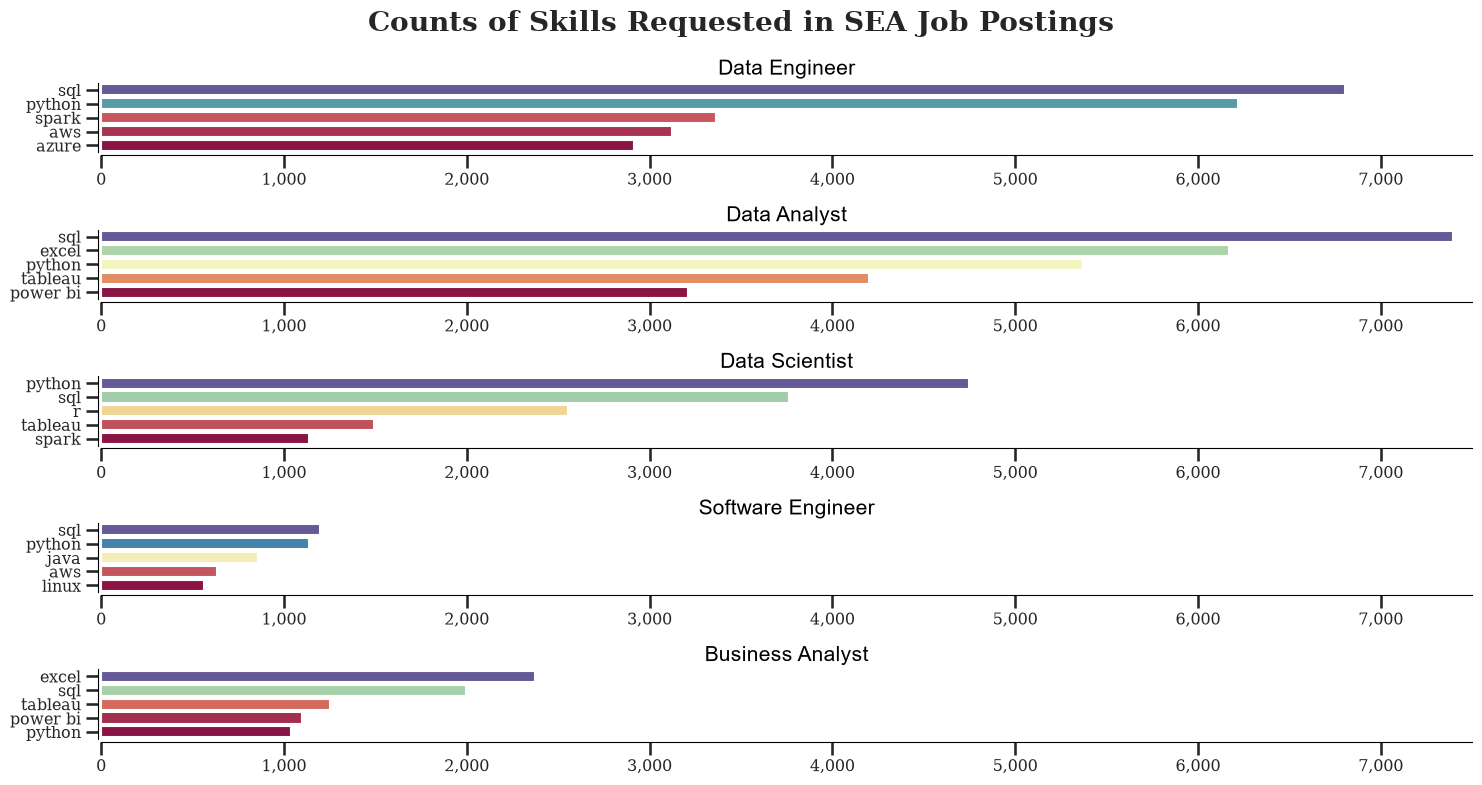

In [11]:
fig, ax = plt.subplots(
                        len(top5_job_title)
                        , 1
                        , figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'Spectral'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.7)

for index, job in enumerate(top5_job_title):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job].head()[::-1]
    sns.barplot(
                data = df_plot
                , x = 'skill_count'
                , y = 'job_skills'
                , ax = ax[index]
                , hue = 'skill_count'
                , palette = 'Spectral'
                , legend = False)

    ax[index].set_title(
                        job
                        , fontsize = 15
                        , loc = 'center')

    ax[index].invert_yaxis()
    ax[index].set_ylabel('')
    ax[index].set_xlabel('')
    ax[index].set_xlim(0, 7500) # make the scales the same
    ax[index].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

sns.despine(offset=2)
fig.suptitle(
            'Counts of Skills Requested in SEA Job Postings'
            , fontsize=20
            , fontweight = 'bold')

fig.tight_layout(h_pad=1) # fix the overlap
plt.show()

### Convert Counts to Percentages

#### Focus: Counts don't show what portions of jobs are requesting these skills

So we'll convert the counts into percentages which helps us understand how each job title represents relative to the entire dataset.

Before we can calculate the percentages we need the total counts for the jobs posted by job title. Calculate the frequency of each job title using the value_counts() method on the job_title_short column. Then reset the index to transform the Series into a DataFrame and renames the columns to job_title_short and total. The DataFrame df_job_title_count now holds a list of job titles alongside their total occurrences.

In [12]:
# Use original df to get the count of job titles
df_job_title_count = df_SEA['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,16242
1,Data Engineer,11801
2,Data Scientist,8095
3,Business Analyst,5770
4,Software Engineer,3899
5,Senior Data Analyst,2428
6,Senior Data Engineer,2141
7,Senior Data Scientist,1568
8,Machine Learning Engineer,1314
9,Cloud Engineer,1171


Then we calculate the percentages. First merge df_skills_count and df_job_title_count, based on the 'job_title_short' column, ensuring each skill count is associated with the total number of job postings for that title. Then calculate the percentage of each skill within its job title by dividing the skill count by the total job postings and multiplying by 100, adding this new data as a 'percentage' column.

In [13]:
df_skill_percent = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

df_skill_percent 

,job_skills,job_title_short,skill_count,jobs_total
0,sql,Data Analyst,7397,16242
1,sql,Data Engineer,6805,11801
2,python,Data Engineer,6217,11801
3,excel,Data Analyst,6168,16242
4,python,Data Analyst,5370,16242
...,...,...,...,...
1700,microsoft teams,Cloud Engineer,1,1171
1701,neo4j,Cloud Engineer,1,1171
1702,wsl,Software Engineer,1,3899
1703,wrike,Business Analyst,1,5770


In [14]:
df_skill_percent['skill_percent'] = (df_skill_percent['skill_count'] / df_skill_percent['jobs_total']) * 100 

df_skill_percent

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,Data Analyst,7397,16242,45.542421
1,sql,Data Engineer,6805,11801,57.664605
2,python,Data Engineer,6217,11801,52.681976
3,excel,Data Analyst,6168,16242,37.975619
4,python,Data Analyst,5370,16242,33.062431
...,...,...,...,...,...
1700,microsoft teams,Cloud Engineer,1,1171,0.085397
1701,neo4j,Cloud Engineer,1,1171,0.085397
1702,wsl,Software Engineer,1,3899,0.025648
1703,wrike,Business Analyst,1,5770,0.017331


### Plot Percentage Count

Filters and sorts a DataFrame to get the top 5 skills percentages for these top 3 roles. After sorting the skills by descending percentage, reverse the order of these top 5 entries to use in a horizontal bar plot, which by default starts plotting from the bottom.

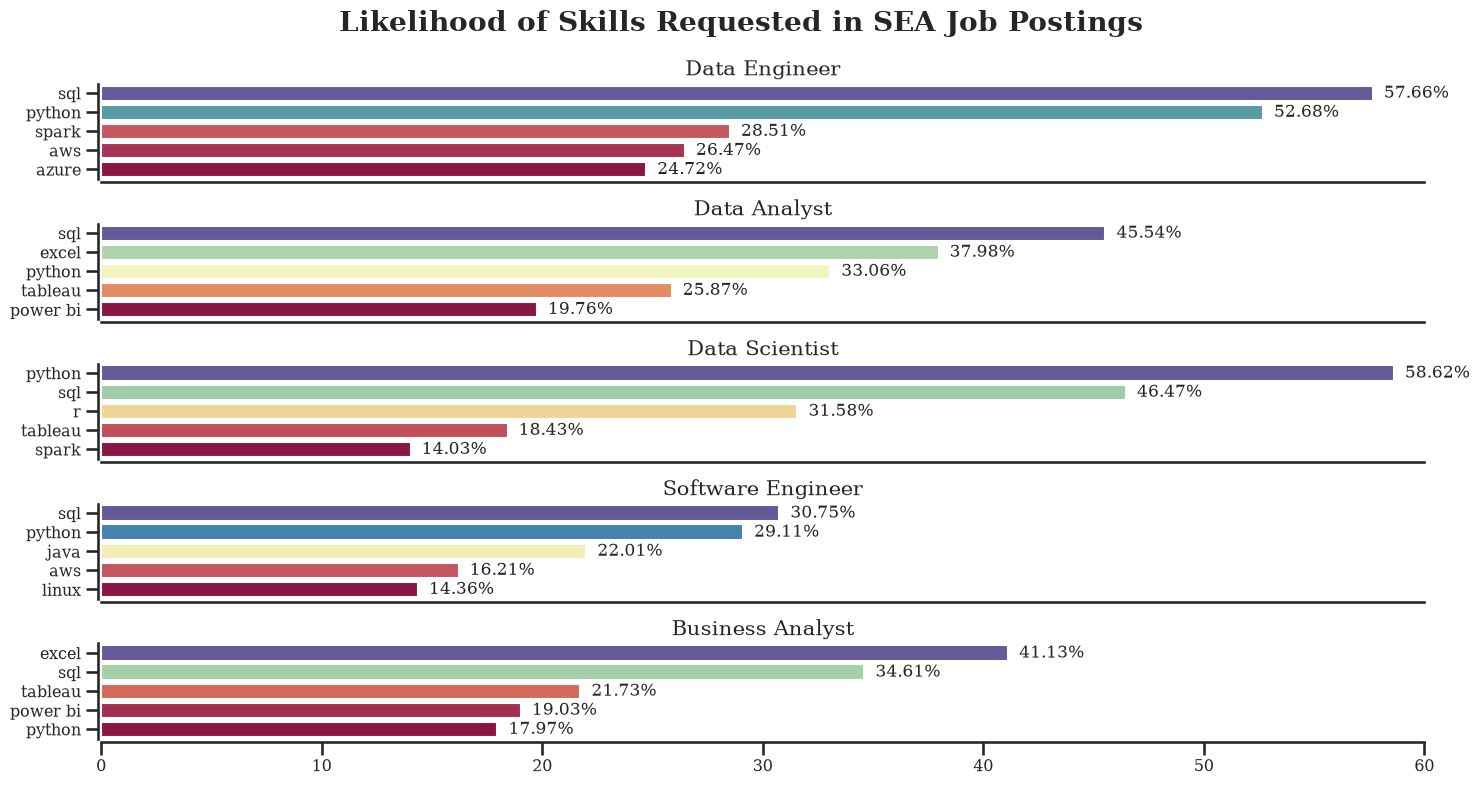

In [15]:
fig, ax = plt.subplots(
                        len(top5_job_title)
                        , 1
                        , figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'Spectral'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.7)

for index, job in enumerate(top5_job_title):
    df_plot = df_skill_percent[df_skill_percent['job_title_short'] == job].head()[::-1]
    sns.barplot(
                data = df_plot
                , x = 'skill_percent'
                , y = 'job_skills'
                , ax = ax[index]
                , hue = 'skill_percent'
                , palette = 'Spectral'
                , legend = False)

    ax[index].set_title(
                        job
                        , fontsize = 15
                        , loc = 'center')

    ax[index].invert_yaxis()
    ax[index].set_ylabel('')
    ax[index].set_xlabel('')
    ax[index].set_xlim(0, 60) # make the scales the same

    # Remove the percentage on first four bar charts
    if index != len(top5_job_title) - 1:
        ax[index].set_xticks([])

    # Label the percentage on all bar charts
    for n, v in enumerate(df_plot['skill_percent']):
        ax[index].text(v + 0.5, n, f'{v:.2f}%', va = 'center')



sns.despine(offset=2)
fig.suptitle(
            'Likelihood of Skills Requested in SEA Job Postings'
            , fontsize=20
            , fontweight = 'bold')

fig.tight_layout(h_pad=1) # fix the overlap
plt.show()